In [1]:
!pip install -q transformers datasets accelerate yfinance scikit-learn
!pip install -q kaggle

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [2]:
FINANCE_FILE = "Major_Data.csv"  # Your finance file name
EMOTION_FILE = "goemotions_2.csv"       # Your emotion file name

In [3]:
import os

if os.path.exists(FINANCE_FILE):
    print(f"✅ Finance file found: {FINANCE_FILE}")
else:
    print(f"❌ Finance file NOT found: {FINANCE_FILE}")
    print(f"   Available files: {[f for f in os.listdir() if f.endswith('.csv')]}")

if os.path.exists(EMOTION_FILE):
    print(f"✅ Emotion file found: {EMOTION_FILE}")
else:
    print(f"❌ Emotion file NOT found: {EMOTION_FILE}")
    print(f"   Available files: {[f for f in os.listdir() if f.endswith('.csv')]}")

✅ Finance file found: Major_Data.csv
✅ Emotion file found: goemotions_2.csv


In [4]:
import pandas as pd
import numpy as np
import torch
from torch.nn.functional import softmax
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
import yfinance as yf
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
# Load and preview finance data
print("📊 FINANCE DATASET:")
finance_df = pd.read_csv(FINANCE_FILE)
print(f"   Shape: {finance_df.shape}")
print(f"   Columns: {list(finance_df.columns)}")
print("\n   First 3 rows:")
display(finance_df.head(3))

# Load and preview emotion data
print("\n😊 EMOTION DATASET:")
emotion_df = pd.read_csv(EMOTION_FILE)
print(f"   Shape: {emotion_df.shape}")
print(f"   Columns: {list(emotion_df.columns)}")
print("\n   First 3 rows:")
display(emotion_df.head(3))

📊 FINANCE DATASET:
   Shape: (20000, 27)
   Columns: ['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']

   First 3 rows:


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422



😊 EMOTION DATASET:
   Shape: (70000, 37)
   Columns: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

   First 3 rows:


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,We can hope,ee3o3ko,darkenseyreth,EdmontonOilers,t3_ag4r9j,t1_ee3mhad,1.547529e+09,62,False,0,...,0,0,1,0,0,0,0,0,0,0
1,Shhh don't give them the idea!,eebl3z7,BoinkBoinkEtAliae,MurderedByWords,t3_ah3o76,t1_eeb68lo,1.547777e+09,76,False,0,...,0,0,0,0,0,0,0,0,0,0
2,"Thank you so much, kind stranger. I really nee...",ed4fe9l,savageleaf,raisedbynarcissists,t3_abwh00,t1_ed4etbj,1.546482e+09,24,False,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
class DatasetIntegrator:
    def __init__(self, finance_path, emotion_path):
        print(f"📂 Loading {finance_path}...")
        self.finance_df = pd.read_csv(finance_path)
        print(f"   → Loaded {len(self.finance_df)} financial records")

        print(f"📂 Loading {emotion_path}...")
        self.emotion_df = pd.read_csv(emotion_path)
        print(f"   → Loaded {len(self.emotion_df)} emotion samples")

    def prepare_finance_data(self):
        expense_cols = [
            'Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
            'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
            'Healthcare', 'Education', 'Miscellaneous'
        ]

        # Only use columns that exist in the dataset
        available_cols = [col for col in expense_cols if col in self.finance_df.columns]

        self.finance_df['Total_Expenses'] = self.finance_df[available_cols].sum(axis=1)
        self.finance_df['Savings'] = self.finance_df['Income'] - self.finance_df['Total_Expenses']
        self.finance_df['Savings_Rate'] = (self.finance_df['Savings'] / self.finance_df['Income']).fillna(0)
        self.finance_df['Debt_to_Income'] = (self.finance_df.get('Loan_Repayment', 0) / self.finance_df['Income']).fillna(0)

        eating_out = self.finance_df.get('Eating_Out', 0)
        entertainment = self.finance_df.get('Entertainment', 0)
        self.finance_df['Discretionary_Ratio'] = ((eating_out + entertainment) / self.finance_df['Income']).fillna(0)

        print("✅ Financial metrics calculated")
        return self.finance_df

    def assign_financial_emotion(self, row):
        savings_rate = row['Savings_Rate']
        debt_ratio = row['Debt_to_Income']

        if savings_rate < 0:
            return 'stressed'
        elif savings_rate < 0.1 and debt_ratio > 0.3:
            return 'stressed'
        elif savings_rate < 0.25:
            return 'neutral'
        else:
            return 'confident'

    def create_emotion_finance_text(self, row):
        income = row['Income']
        savings = row['Savings']
        savings_rate = row['Savings_Rate'] * 100

        text_parts = [
            f"Monthly income of ₹{income:.0f}",
            f"with savings of ₹{savings:.0f}",
            f"representing {savings_rate:.1f}% savings rate"
        ]

        if row.get('Loan_Repayment', 0) > 0:
            text_parts.append(f"paying ₹{row['Loan_Repayment']:.0f} in loan EMI")

        if row['Discretionary_Ratio'] > 0.15:
            text_parts.append("with moderate discretionary spending")

        return ". ".join(text_parts) + "."

    def create_training_dataset(self):
        print("🔄 Creating training dataset...")

        finance_prepared = self.prepare_finance_data()
        training_data = []

        for idx, row in finance_prepared.iterrows():
            text = self.create_emotion_finance_text(row)
            label = self.assign_financial_emotion(row)

            training_data.append({
                'text': text,
                'label': label,
                'income': row['Income'],
                'savings': row['Savings'],
                'savings_rate': row['Savings_Rate']
            })

        result_df = pd.DataFrame(training_data)
        print(f"✅ Created {len(result_df)} training samples")
        print(f"\n   Label distribution:")
        print(result_df['label'].value_counts())

        return result_df

print("✅ DatasetIntegrator class defined")

✅ DatasetIntegrator class defined


In [7]:
def compute_investable_amount(row, emotion_factor=1.0):
    expense_cols = [
        'Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
        'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
        'Healthcare', 'Education', 'Miscellaneous'
    ]

    monthly_expenses = sum([row.get(col, 0) for col in expense_cols])
    savings = row['Income'] - monthly_expenses

    if savings <= 0:
        return 0.0

    emergency_fund_needed = monthly_expenses * 3
    emergency_fund_current = row.get('Emergency_Fund', 0)

    if emergency_fund_current < emergency_fund_needed:
        investable = savings * 0.5
    else:
        investable = savings * 0.8

    return investable * emotion_factor

print("✅ Investment calculation function defined")

✅ Investment calculation function defined


In [8]:
# class EmotionModelTrainer:
#     def __init__(self, model_name="distilbert-base-uncased", output_dir="./emotion_model"):
#         self.model_name = model_name
#         self.output_dir = output_dir
#         self.labels = ["stressed", "neutral", "confident"]
#         self.label2id = {l: i for i, l in enumerate(self.labels)}
#         self.id2label = {i: l for l, i in self.label2id.items()}

#     def prepare_dataset(self, train_df, val_df, max_length=128):
#         print("🔤 Loading tokenizer...")
#         self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)

#         def tokenize_function(examples):
#             tokenized = self.tokenizer(
#                 examples['text'],
#                 truncation=True,
#                 padding='max_length',
#                 max_length=max_length
#             )
#             tokenized['labels'] = [self.label2id[label] for label in examples['label']]
#             return tokenized

#         print("🔄 Converting to HuggingFace Dataset...")
#         train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
#         val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

#         print("🔤 Tokenizing...")
#         train_dataset = train_dataset.map(tokenize_function, batched=True)
#         val_dataset = val_dataset.map(tokenize_function, batched=True)

#         print("✅ Dataset prepared")
#         return train_dataset, val_dataset

#     def train(self, train_dataset, val_dataset, epochs=3, batch_size=16):
#         print(f"📥 Loading {self.model_name}...")
#         model = AutoModelForSequenceClassification.from_pretrained(
#             self.model_name,
#             num_labels=len(self.labels),
#             label2id=self.label2id,
#             id2label=self.id2label
#         )

#         training_args = TrainingArguments(
#             output_dir=self.output_dir,
#             eval_strategy="epoch",
#             save_strategy="epoch",
#             per_device_train_batch_size=batch_size,
#             per_device_eval_batch_size=batch_size,
#             num_train_epochs=epochs,
#             load_best_model_at_end=True,
#             metric_for_best_model="eval_loss",
#             report_to="none",
#             logging_steps=50
#         )

#         trainer = Trainer(
#             model=model,
#             args=training_args,
#             train_dataset=train_dataset,
#             eval_dataset=val_dataset,
#             #tokenizer=self.tokenizer
#         )

#         print("\n🚀 Starting training...")
#         print("="*70)
#         trainer.train()

#         print("\n💾 Saving model...")
#         model.save_pretrained(self.output_dir)
#         self.tokenizer.save_pretrained(self.output_dir)
#         print(f"✅ Model saved to {self.output_dir}")

#         return model

# print("✅ EmotionModelTrainer class defined")
# ============================================================
# QUICK FIX - Run this cell to replace the broken trainer
# ============================================================

class EmotionModelTrainer:
    """Fixed version that properly handles dataset formatting"""

    def __init__(self, model_name="distilbert-base-uncased", output_dir="./emotion_model"):
        self.model_name = model_name
        self.output_dir = output_dir
        self.labels = ["stressed", "neutral", "confident"]
        self.label2id = {l: i for i, l in enumerate(self.labels)}
        self.id2label = {i: l for l, i in self.label2id.items()}

    def prepare_dataset(self, train_df, val_df, max_length=128):
        """Tokenize and prepare dataset - FIXED VERSION"""
        print("🔤 Loading tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)

        def tokenize_function(examples):
            tokenized = self.tokenizer(
                examples['text'],
                truncation=True,
                padding='max_length',
                max_length=max_length
            )
            # Convert string labels to integers
            tokenized['labels'] = [self.label2id[label] for label in examples['label']]
            return tokenized

        print("🔄 Converting to HuggingFace Dataset...")
        # Reset index to avoid issues
        train_dataset = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
        val_dataset = Dataset.from_pandas(val_df[['text', 'label']].reset_index(drop=True))

        print("🔤 Tokenizing...")
        # KEY FIX: Remove original columns that cause conflicts
        train_dataset = train_dataset.map(
            tokenize_function,
            batched=True,
            remove_columns=train_dataset.column_names  # Removes 'text' and 'label' strings
        )
        val_dataset = val_dataset.map(
            tokenize_function,
            batched=True,
            remove_columns=val_dataset.column_names
        )

        # Explicitly set PyTorch format
        train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
        val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

        print("✅ Dataset prepared with proper formatting")
        return train_dataset, val_dataset

    def train(self, train_dataset, val_dataset, epochs=3, batch_size=16):
        """Train the emotion classification model"""
        print(f"📥 Loading {self.model_name}...")
        model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=len(self.labels),
            label2id=self.label2id,
            id2label=self.id2label
        )

        training_args = TrainingArguments(
            output_dir=self.output_dir,
            eval_strategy="epoch",
            save_strategy="epoch",
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=epochs,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            report_to="none",
            logging_steps=50,
            save_total_limit=2  # Only keep best 2 checkpoints
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            #tokenizer=self.tokenizer
        )

        print("\n🚀 Starting training...")
        print("="*70)
        trainer.train()

        print("\n💾 Saving model...")
        model.save_pretrained(self.output_dir)
        self.tokenizer.save_pretrained(self.output_dir)
        print(f"✅ Model saved to {self.output_dir}")

        return model

print("✅ Fixed EmotionModelTrainer class loaded!")
print("\n📝 Now run your training pipeline again:")
print("   trainer = EmotionModelTrainer(output_dir='./emotion_finance_model')")
print("   train_dataset, val_dataset = trainer.prepare_dataset(train_df, val_df)")
print("   model = trainer.train(train_dataset, val_dataset, epochs=3, batch_size=16)")

✅ Fixed EmotionModelTrainer class loaded!

📝 Now run your training pipeline again:
   trainer = EmotionModelTrainer(output_dir='./emotion_finance_model')
   train_dataset, val_dataset = trainer.prepare_dataset(train_df, val_df)
   model = trainer.train(train_dataset, val_dataset, epochs=3, batch_size=16)


In [9]:
class FinancialEmotionAdvisor:
    def __init__(self, model_dir):
        print(f"📥 Loading model from {model_dir}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_dir)
        self.model.eval()

        self.emotion_risk_factors = {
            'stressed': 0.3,
            'neutral': 0.6,
            'confident': 0.8
        }
        print("✅ Advisor initialized")

    def create_user_text(self, user_row):
        income = user_row['Income']
        expense_cols = [
            'Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
            'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
            'Healthcare', 'Education', 'Miscellaneous'
        ]
        expenses = sum([user_row.get(col, 0) for col in expense_cols])
        savings = income - expenses
        savings_rate = (savings / income * 100) if income > 0 else 0

        return f"Monthly income of ₹{income:.0f} with savings of ₹{savings:.0f} representing {savings_rate:.1f}% savings rate."

    def analyze(self, user_row):
        text = self.create_user_text(user_row)
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

        with torch.no_grad():
            logits = self.model(**inputs).logits

        probs = softmax(logits, dim=1)[0].numpy()
        predicted_idx = int(probs.argmax())
        emotion = self.model.config.id2label[predicted_idx]
        confidence = float(probs[predicted_idx])

        emotion_factor = self.emotion_risk_factors[emotion]
        investable = compute_investable_amount(user_row, emotion_factor)

        return emotion, confidence, investable

print("✅ FinancialEmotionAdvisor class defined")

✅ FinancialEmotionAdvisor class defined


In [10]:
class MarketAdvisor:
    def advise(self, ticker, period="6mo"):
        print(f"📊 Fetching market data for {ticker}...")
        df = yf.download(ticker, period=period, progress=False)

        if df.empty:
            return {
                "trend": "unknown",
                "last_price": 0,
                "recommendation": "Unable to fetch market data"
            }

        df['ma20'] = df['Close'].rolling(20).mean()
        df['ma50'] = df['Close'].rolling(50).mean()

        last_close = float(df['Close'].iloc[-1])
        ma20 = float(df['ma20'].iloc[-1])
        ma50 = float(df['ma50'].iloc[-1])

        trend = "bullish" if ma20 > ma50 else "bearish"
        price_above_ma20 = last_close > ma20

        if trend == "bullish" and price_above_ma20:
            recommendation = "Strong buy signal - uptrend confirmed"
        elif trend == "bullish":
            recommendation = "Wait for dip to MA20 before buying"
        elif trend == "bearish" and not price_above_ma20:
            recommendation = "Avoid - downtrend continues"
        else:
            recommendation = "Cautious - possible trend reversal"

        print(f"✅ Market analysis complete: {trend.upper()}")

        return {
            "trend": trend,
            "last_price": last_close,
            "ma20": ma20,
            "ma50": ma50,
            "recommendation": recommendation
        }

class TradingExecutor:
    def __init__(self, dry_run=True):
        self.dry_run = dry_run
        self.trade_history = []

    def place_order(self, symbol, side, qty, price, reason):
        order = {
            'symbol': symbol,
            'side': side,
            'quantity': qty,
            'price': price,
            'total_value': qty * price,
            'reason': reason,
            'status': 'SIMULATED' if self.dry_run else 'EXECUTED'
        }

        self.trade_history.append(order)

        if self.dry_run:
            return f"[SIMULATION] {side} {qty} shares of {symbol} @ ₹{price:.2f} = ₹{order['total_value']:.2f}"

        return f"[LIVE] Order placed: {side} {qty} {symbol}"

    def get_trade_summary(self):
        return pd.DataFrame(self.trade_history)

def execute_trading_strategy(user_data, advisor, market_analyzer, executor, symbol="RELIANCE.NS"):
    print("\n" + "="*70)
    print("🎯 EXECUTING TRADING STRATEGY")
    print("="*70)

    print("\n📊 Analyzing user financial profile...")
    emotion, confidence, investable = advisor.analyze(user_data)

    market_signal = market_analyzer.advise(symbol)

    result = {
        'emotion': emotion,
        'emotion_confidence': confidence,
        'investable_amount': investable,
        'market_trend': market_signal['trend'],
        'last_price': market_signal['last_price'],
        'market_recommendation': market_signal['recommendation'],
        'action': None,
        'message': []
    }

    if investable <= 0:
        result['action'] = 'HOLD'
        result['message'].append("❌ No surplus capital available for investment")
        return result

    if emotion == 'stressed':
        result['action'] = 'HOLD'
        result['message'].append("⚠️ Financial stress detected - focus on expense reduction first")
        result['message'].append("💡 Build emergency fund before investing")
        return result

    last_price = market_signal['last_price']
    max_qty = int(investable // last_price)

    if max_qty == 0:
        result['action'] = 'HOLD'
        result['message'].append(f"❌ Insufficient funds - need ₹{last_price:.2f} minimum")
        return result

    if emotion == 'confident' and market_signal['trend'] == 'bullish':
        qty = max_qty
        action_taken = executor.place_order(symbol, 'BUY', qty, last_price, f"Confident + Bullish")
        result['action'] = 'BUY'
        result['quantity'] = qty
        result['message'].append(f"✅ {action_taken}")
        result['message'].append(f"📈 Strong position: investing ₹{qty * last_price:.2f}")

    elif emotion == 'neutral' and market_signal['trend'] == 'bullish':
        qty = max(1, max_qty // 2)
        action_taken = executor.place_order(symbol, 'BUY', qty, last_price, f"Neutral + Bullish")
        result['action'] = 'BUY'
        result['quantity'] = qty
        result['message'].append(f"✅ {action_taken}")
        result['message'].append(f"📊 Moderate position: investing ₹{qty * last_price:.2f}")

    elif market_signal['trend'] == 'bearish':
        result['action'] = 'HOLD'
        result['message'].append("📉 Bearish market - waiting for better entry")
        result['message'].append(f"💰 Keeping ₹{investable:.2f} liquid")

    else:
        result['action'] = 'HOLD'
        result['message'].append("⏸️ Mixed signals - holding position")

    return result

print("✅ All trading classes defined")

✅ All trading classes defined


In [11]:
print("="*70)
print("🚀 EMOTION-AWARE FINANCIAL TRADING SYSTEM")
print("="*70)

# Step 1: Integrate datasets
print("\n📊 STEP 1: Data Integration")
integrator = DatasetIntegrator(FINANCE_FILE, EMOTION_FILE)
training_data = integrator.create_training_dataset()

# Step 2: Split data
print("\n✂️ STEP 2: Train/Validation Split")
train_df, val_df = train_test_split(training_data, test_size=0.2, random_state=42)
print(f"   📝 Train: {len(train_df)} | Validation: {len(val_df)}")

# Step 3: Train model
print("\n🤖 STEP 3: Model Training")
trainer = EmotionModelTrainer(output_dir="./emotion_finance_model")
train_dataset, val_dataset = trainer.prepare_dataset(train_df, val_df)
model = trainer.train(train_dataset, val_dataset, epochs=3, batch_size=16)

print("\n✅ MODEL TRAINING COMPLETE!")
print("="*70)

🚀 EMOTION-AWARE FINANCIAL TRADING SYSTEM

📊 STEP 1: Data Integration
📂 Loading Major_Data.csv...
   → Loaded 20000 financial records
📂 Loading goemotions_2.csv...
   → Loaded 70000 emotion samples
🔄 Creating training dataset...
✅ Financial metrics calculated
✅ Created 20000 training samples

   Label distribution:
label
confident    10879
neutral       9009
stressed       112
Name: count, dtype: int64

✂️ STEP 2: Train/Validation Split
   📝 Train: 16000 | Validation: 4000

🤖 STEP 3: Model Training
🔤 Loading tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



💾 Saving model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to ./emotion_finance_model

✅ MODEL TRAINING COMPLETE!


In [12]:
# Initialize components
advisor = FinancialEmotionAdvisor(model_dir="./emotion_finance_model")
market_analyzer = MarketAdvisor()
executor = TradingExecutor(dry_run=True)

# Demo profile
demo_user = {
    'Income': 60000,
    'Rent': 15000,
    'Loan_Repayment': 8000,
    'Insurance': 2000,
    'Groceries': 6000,
    'Transport': 3000,
    'Eating_Out': 2500,
    'Entertainment': 2000,
    'Utilities': 3000,
    'Healthcare': 1500,
    'Education': 0,
    'Miscellaneous': 1000,
    'Emergency_Fund': 50000
}

result = execute_trading_strategy(
    user_data=demo_user,
    advisor=advisor,
    market_analyzer=market_analyzer,
    executor=executor,
    symbol="RELIANCE.NS"
)

# Display results
print("\n" + "="*70)
print("📋 DEMO RESULTS")
print("="*70)
print(f"\n💭 Emotion: {result['emotion'].upper()} ({result['emotion_confidence']:.1%})")
print(f"💰 Investable: ₹{result['investable_amount']:.2f}")
print(f"📈 Market: {result['market_trend'].upper()}")
print(f"💵 Price: ₹{result['last_price']:.2f}")
print(f"🎯 Action: {result['action']}")
print("\n💡 Details:")
for msg in result['message']:
    print(f"   {msg}")

📥 Loading model from ./emotion_finance_model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Advisor initialized

🎯 EXECUTING TRADING STRATEGY

📊 Analyzing user financial profile...
📊 Fetching market data for RELIANCE.NS...
✅ Market analysis complete: BEARISH

📋 DEMO RESULTS

💭 Emotion: CONFIDENT (100.0%)
💰 Investable: ₹6400.00
📈 Market: BEARISH
💵 Price: ₹1419.60
🎯 Action: HOLD

💡 Details:
   📉 Bearish market - waiting for better entry
   💰 Keeping ₹6400.00 liquid


In [13]:
# 🔧 EDIT YOUR PROFILE HERE

my_profile = {
    'Income': 80000,
    'Rent': 20000,
    'Loan_Repayment': 5000,
    'Insurance': 3000,
    'Groceries': 8000,
    'Transport': 4000,
    'Eating_Out': 3000,
    'Entertainment': 2000,
    'Utilities': 3500,
    'Healthcare': 2000,
    'Education': 0,
    'Miscellaneous': 1500,
    'Emergency_Fund': 100000
}

stock_symbol = "TCS.NS"  # Change to: INFY.NS, HDFCBANK.NS, etc.

my_result = execute_trading_strategy(
    user_data=my_profile,
    advisor=advisor,
    market_analyzer=market_analyzer,
    executor=executor,
    symbol=stock_symbol
)

print("\n" + "="*70)
print("🎨 YOUR RESULTS")
print("="*70)
print(f"\n💭 Emotion: {my_result['emotion'].upper()} ({my_result['emotion_confidence']:.1%})")
print(f"💰 Investable: ₹{my_result['investable_amount']:.2f}")
print(f"📈 Market: {my_result['market_trend'].upper()}")
print(f"💵 Price: ₹{my_result['last_price']:.2f}")
print(f"🎯 Action: {my_result['action']}")

if 'quantity' in my_result:
    total = my_result['quantity'] * my_result['last_price']
    print(f"\n📊 Trade: {my_result['quantity']} shares × ₹{my_result['last_price']:.2f} = ₹{total:.2f}")

print("\n💡 Recommendations:")
for msg in my_result['message']:
    print(f"   {msg}")


🎯 EXECUTING TRADING STRATEGY

📊 Analyzing user financial profile...
📊 Fetching market data for TCS.NS...
✅ Market analysis complete: BEARISH

🎨 YOUR RESULTS

💭 Emotion: CONFIDENT (100.0%)
💰 Investable: ₹11200.00
📈 Market: BEARISH
💵 Price: ₹2692.20
🎯 Action: HOLD

💡 Recommendations:
   📉 Bearish market - waiting for better entry
   💰 Keeping ₹11200.00 liquid


📊 COMPUTING MODEL ACCURACY

🚀 Method 1: Using Trainer Evaluation...



🎯 OVERALL ACCURACY: 99.92%

📋 CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

   confident      0.999     1.000     0.999      2175
     neutral      1.000     0.998     0.999      1792
    stressed      1.000     1.000     1.000        33

    accuracy                          0.999      4000
   macro avg      1.000     0.999     0.999      4000
weighted avg      0.999     0.999     0.999      4000


📊 PER-CLASS ACCURACY:
----------------------------------------------------------------------
   STRESSED     → 100.00%  (33/33 correct)
   NEUTRAL      → 99.83%  (1789/1792 correct)
   CONFIDENT    → 100.00%  (2175/2175 correct)

🔢 CONFUSION MATRIX:
----------------------------------------------------------------------

                           Predicted →               
True ↓         Stressed     Neutral     Confident  
------------------------------------------------------------
Stre

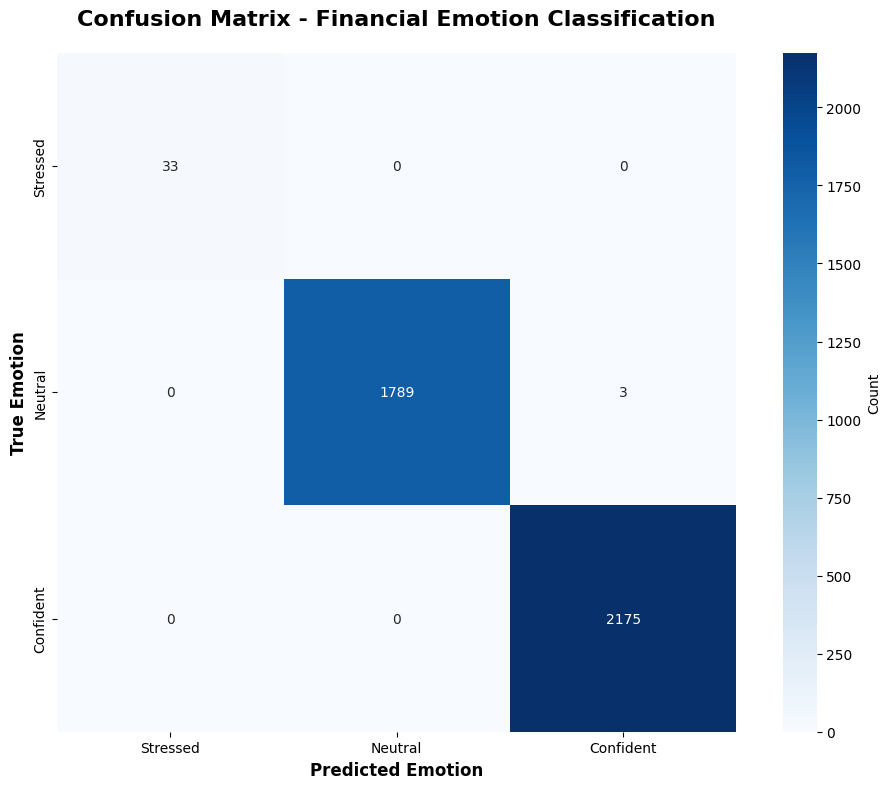


📈 PREDICTION CONFIDENCE:
----------------------------------------------------------------------
   Mean Confidence: 99.90%
   Median Confidence: 100.00%
   Min Confidence: 52.39%
   Max Confidence: 100.00%

   Confidence when CORRECT: 99.94%
   Confidence when WRONG: 52.90%


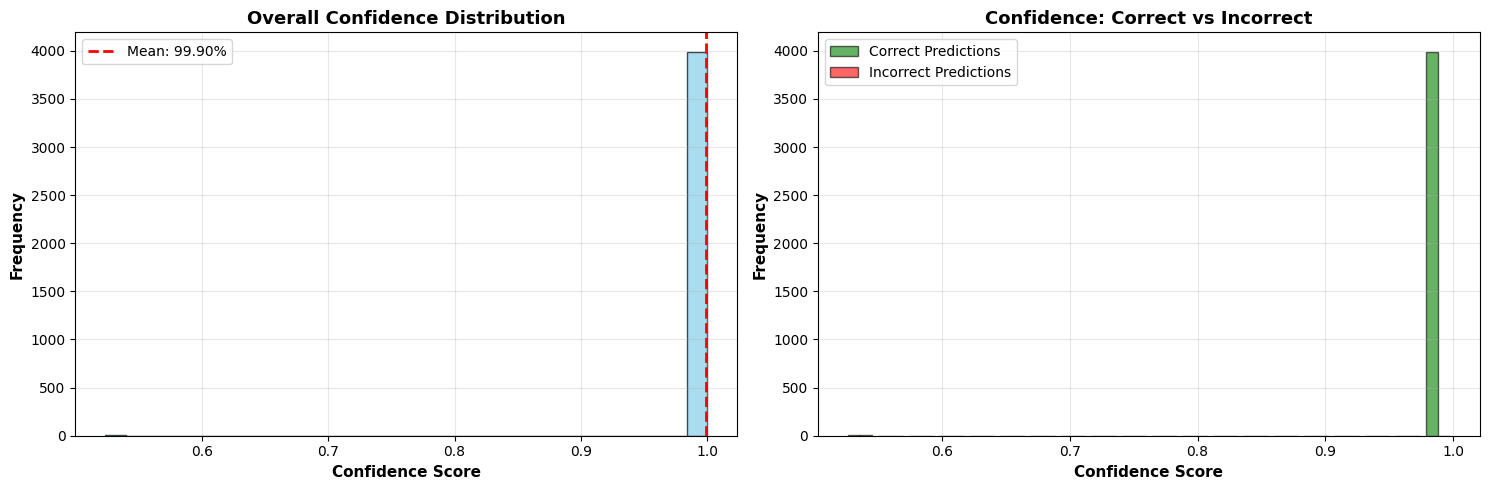


❌ ERROR ANALYSIS:
----------------------------------------------------------------------
   Total Errors: 3 / 4000 (0.07%)

   Most common misclassifications:
      neutral → confident: 3 times (100.0% of errors)

⚠️  LOW CONFIDENCE PREDICTIONS (< 60%):
   Count: 8 / 4000 (0.20%)
   Accuracy on low-confidence: 62.50%

✅ EVALUATION COMPLETE

📌 PERFORMANCE SUMMARY:
   🎯 Overall Accuracy: 99.92%
   ❌ Error Rate: 0.07%
   💪 Mean Confidence: 99.90%
   📊 Total Samples: 4000
   ✅ Correct Predictions: 3997
   ❌ Incorrect Predictions: 3

   Model Quality: 🌟 EXCELLENT


In [14]:
# ============================================================
# QUICK ACCURACY COMPUTATION (FASTER METHOD)
# Run this cell after training completes
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 COMPUTING MODEL ACCURACY")
print("="*70)

# Method 1: Use the trainer's evaluate function (fastest)
print("\n🚀 Method 1: Using Trainer Evaluation...")

# Create a new trainer just for evaluation
from transformers import Trainer

eval_trainer = Trainer(
    model=model,
    eval_dataset=val_dataset,
    #tokenizer=trainer.tokenizer
)

# Get predictions
predictions_output = eval_trainer.predict(val_dataset)
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convert logits to predicted classes
predicted_labels = np.argmax(logits, axis=1)

# Label mapping
id2label = {0: 'stressed', 1: 'neutral', 2: 'confident'}
label2id = {v: k for k, v in id2label.items()}

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

print("\n" + "="*70)
print(f"🎯 OVERALL ACCURACY: {accuracy:.2%}")
print("="*70)

# Detailed metrics
print("\n📋 CLASSIFICATION REPORT:")
print("-"*70)

# Convert numeric labels back to strings for the report
true_labels_str = [id2label[i] for i in true_labels]
pred_labels_str = [id2label[i] for i in predicted_labels]

report = classification_report(
    true_labels_str,
    pred_labels_str,
    digits=3
)
print(report)

# Per-class breakdown
print("\n📊 PER-CLASS ACCURACY:")
print("-"*70)
for label_name, label_id in label2id.items():
    mask = true_labels == label_id
    if mask.sum() > 0:
        class_acc = (predicted_labels[mask] == label_id).sum() / mask.sum()
        total = mask.sum()
        correct = (predicted_labels[mask] == label_id).sum()
        print(f"   {label_name.upper():12} → {class_acc:6.2%}  ({correct}/{total} correct)")

# Confusion Matrix
print("\n🔢 CONFUSION MATRIX:")
print("-"*70)

cm = confusion_matrix(true_labels, predicted_labels)
labels_display = ['Stressed', 'Neutral', 'Confident']

# Print as table
print(f"\n{'':12} {'Predicted →':^40}")
print(f"{'True ↓':12} {labels_display[0]:^12} {labels_display[1]:^12} {labels_display[2]:^12}")
print("-"*60)
for i, true_label in enumerate(labels_display):
    row_str = f"{true_label:12}"
    for j in range(3):
        row_str += f" {cm[i][j]:^12}"
    print(row_str)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_display,
    yticklabels=labels_display,
    cbar_kws={'label': 'Count'},
    square=True
)
plt.title('Confusion Matrix - Financial Emotion Classification', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Confidence scores
print("\n📈 PREDICTION CONFIDENCE:")
print("-"*70)

# Get softmax probabilities
from torch.nn.functional import softmax
import torch

probs = softmax(torch.tensor(logits), dim=1).numpy()
max_probs = probs.max(axis=1)

print(f"   Mean Confidence: {max_probs.mean():.2%}")
print(f"   Median Confidence: {np.median(max_probs):.2%}")
print(f"   Min Confidence: {max_probs.min():.2%}")
print(f"   Max Confidence: {max_probs.max():.2%}")

# Confidence by correctness
correct_mask = predicted_labels == true_labels
correct_conf = max_probs[correct_mask].mean()
incorrect_conf = max_probs[~correct_mask].mean()

print(f"\n   Confidence when CORRECT: {correct_conf:.2%}")
print(f"   Confidence when WRONG: {incorrect_conf:.2%}")

# Visualize confidence distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Overall confidence distribution
ax1.hist(max_probs, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(max_probs.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {max_probs.mean():.2%}')
ax1.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Overall Confidence Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Confidence by correctness
correct_conf_vals = max_probs[correct_mask]
incorrect_conf_vals = max_probs[~correct_mask]

ax2.hist([correct_conf_vals, incorrect_conf_vals], bins=20,
         label=['Correct Predictions', 'Incorrect Predictions'],
         color=['green', 'red'], alpha=0.6, edgecolor='black')
ax2.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Confidence: Correct vs Incorrect', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Error analysis
print("\n❌ ERROR ANALYSIS:")
print("-"*70)

error_count = (~correct_mask).sum()
error_rate = error_count / len(true_labels)

print(f"   Total Errors: {error_count} / {len(true_labels)} ({error_rate:.2%})")

# Find most common errors
if error_count > 0:
    error_pairs = []
    for i in range(len(true_labels)):
        if not correct_mask[i]:
            error_pairs.append((id2label[true_labels[i]], id2label[predicted_labels[i]]))

    from collections import Counter
    error_counts = Counter(error_pairs)

    print(f"\n   Most common misclassifications:")
    for (true_label, pred_label), count in error_counts.most_common(3):
        pct = count / error_count * 100
        print(f"      {true_label} → {pred_label}: {count} times ({pct:.1f}% of errors)")

# Low confidence predictions
low_conf_threshold = 0.6
low_conf_mask = max_probs < low_conf_threshold
low_conf_count = low_conf_mask.sum()

print(f"\n⚠️  LOW CONFIDENCE PREDICTIONS (< {low_conf_threshold:.0%}):")
print(f"   Count: {low_conf_count} / {len(max_probs)} ({low_conf_count/len(max_probs):.2%})")

if low_conf_count > 0:
    low_conf_accuracy = correct_mask[low_conf_mask].mean()
    print(f"   Accuracy on low-confidence: {low_conf_accuracy:.2%}")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE")
print("="*70)

# Final summary
print("\n📌 PERFORMANCE SUMMARY:")
print(f"   🎯 Overall Accuracy: {accuracy:.2%}")
print(f"   ❌ Error Rate: {error_rate:.2%}")
print(f"   💪 Mean Confidence: {max_probs.mean():.2%}")
print(f"   📊 Total Samples: {len(true_labels)}")
print(f"   ✅ Correct Predictions: {correct_mask.sum()}")
print(f"   ❌ Incorrect Predictions: {error_count}")

# Model quality assessment
if accuracy >= 0.90:
    quality = "🌟 EXCELLENT"
elif accuracy >= 0.80:
    quality = "✅ GOOD"
elif accuracy >= 0.70:
    quality = "⚠️  FAIR"
else:
    quality = "❌ NEEDS IMPROVEMENT"

print(f"\n   Model Quality: {quality}")

In [15]:
# ============================================================
# EMOTION-AWARE PERSONALIZATION ENGINE
# Add this cell to enable personalized recommendations
# ============================================================

class EmotionAwarePersonalizer:
    """
    Generates personalized financial advice based on emotional state,
    spending patterns, and financial goals.
    """

    def __init__(self, advisor_model):
        self.advisor = advisor_model

        # Personalization rules by emotion
        self.emotion_strategies = {
            'stressed': {
                'risk_tolerance': 'low',
                'focus': 'stability',
                'investment_types': ['Fixed Deposits', 'Government Bonds', 'Liquid Funds'],
                'action_priority': ['Build Emergency Fund', 'Reduce Debt', 'Cut Discretionary Spending']
            },
            'neutral': {
                'risk_tolerance': 'moderate',
                'focus': 'balanced_growth',
                'investment_types': ['Index Funds', 'Balanced Mutual Funds', 'Blue-chip Stocks'],
                'action_priority': ['Start SIP', 'Diversify Portfolio', 'Tax Planning']
            },
            'confident': {
                'risk_tolerance': 'high',
                'focus': 'wealth_building',
                'investment_types': ['Growth Stocks', 'Equity Mutual Funds', 'Sectoral Funds'],
                'action_priority': ['Maximize Investments', 'Explore New Opportunities', 'Long-term Wealth']
            }
        }

    def analyze_spending_patterns(self, user_data):
        """Identify spending behavior and suggest improvements"""

        income = user_data['Income']

        # Calculate category percentages
        categories = {
            'Housing': user_data.get('Rent', 0),
            'Debt': user_data.get('Loan_Repayment', 0),
            'Insurance': user_data.get('Insurance', 0),
            'Food': user_data.get('Groceries', 0) + user_data.get('Eating_Out', 0),
            'Transport': user_data.get('Transport', 0),
            'Entertainment': user_data.get('Entertainment', 0),
            'Utilities': user_data.get('Utilities', 0),
            'Healthcare': user_data.get('Healthcare', 0),
            'Education': user_data.get('Education', 0),
            'Miscellaneous': user_data.get('Miscellaneous', 0)
        }

        patterns = {}
        alerts = []

        for category, amount in categories.items():
            pct = (amount / income * 100) if income > 0 else 0
            patterns[category] = {'amount': amount, 'percentage': pct}

            # Alert thresholds
            if category == 'Housing' and pct > 30:
                alerts.append(f"⚠️ Housing costs ({pct:.1f}%) exceed recommended 30% of income")
            elif category == 'Debt' and pct > 20:
                alerts.append(f"🔴 Debt payments ({pct:.1f}%) are high - prioritize debt reduction")
            elif category == 'Entertainment' and pct > 10:
                alerts.append(f"💡 Entertainment spending ({pct:.1f}%) could be optimized")
            elif category == 'Food' and pct > 15:
                alerts.append(f"🍽️ Food expenses ({pct:.1f}%) are above average - consider meal planning")

        return patterns, alerts

    def generate_personalized_plan(self, user_data):
        """Create comprehensive personalized financial plan"""

        print("\n" + "="*70)
        print("🎯 GENERATING PERSONALIZED FINANCIAL PLAN")
        print("="*70)

        # Analyze emotion
        emotion, confidence, investable = self.advisor.analyze(user_data)
        strategy = self.emotion_strategies[emotion]

        # Analyze spending
        patterns, alerts = self.analyze_spending_patterns(user_data)

        # Calculate metrics
        income = user_data['Income']
        total_expenses = sum([user_data.get(col, 0) for col in [
            'Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
            'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
            'Healthcare', 'Education', 'Miscellaneous'
        ]])
        savings = income - total_expenses
        savings_rate = (savings / income * 100) if income > 0 else 0

        emergency_fund = user_data.get('Emergency_Fund', 0)
        emergency_needed = total_expenses * 6  # 6 months recommended
        emergency_coverage = (emergency_fund / emergency_needed * 100) if emergency_needed > 0 else 0

        # Generate report
        report = {
            'emotion': emotion,
            'confidence': confidence,
            'risk_profile': strategy['risk_tolerance'],
            'financial_focus': strategy['focus'],
            'metrics': {
                'monthly_income': income,
                'total_expenses': total_expenses,
                'monthly_savings': savings,
                'savings_rate': savings_rate,
                'investable_amount': investable,
                'emergency_fund': emergency_fund,
                'emergency_coverage': emergency_coverage
            },
            'spending_patterns': patterns,
            'alerts': alerts,
            'recommended_investments': strategy['investment_types'],
            'action_priorities': strategy['action_priority'],
            'personalized_tips': self._generate_tips(emotion, savings_rate, emergency_coverage, patterns)
        }

        return report

    def _generate_tips(self, emotion, savings_rate, emergency_coverage, patterns):
        """Generate contextual tips based on user profile"""

        tips = []

        # Emotion-based tips
        if emotion == 'stressed':
            tips.append("🧘 Focus on financial stability before aggressive investments")
            tips.append("📊 Track expenses daily to identify quick wins")
            if emergency_coverage < 100:
                tips.append(f"🚨 Priority: Build emergency fund to {100-emergency_coverage:.0f}% more")

        elif emotion == 'neutral':
            tips.append("📈 You're in a good position to start systematic investing")
            tips.append("🎯 Consider starting a monthly SIP in index funds")
            tips.append("💼 Review and increase insurance coverage if needed")

        elif emotion == 'confident':
            tips.append("🚀 Strong financial position - consider growth investments")
            tips.append("🌍 Explore diversification into different asset classes")
            tips.append("📚 Good time to learn about advanced investment strategies")

        # Savings-based tips
        if savings_rate < 10:
            tips.append("💰 Aim to increase savings rate to at least 20%")
        elif savings_rate > 30:
            tips.append("⭐ Excellent savings rate! Optimize investment allocation")

        # Pattern-based tips
        eating_out_pct = patterns.get('Food', {}).get('percentage', 0)
        if eating_out_pct > 12:
            tips.append("🍳 Meal prep can save ₹2000-5000/month on food")

        return tips

    def display_report(self, report):
        """Display formatted personalized report"""

        print(f"\n{'='*70}")
        print(f"👤 YOUR PERSONALIZED FINANCIAL PROFILE")
        print(f"{'='*70}")

        # Emotional State
        print(f"\n💭 Emotional Financial State: {report['emotion'].upper()}")
        print(f"   Confidence: {report['confidence']:.1%}")
        print(f"   Risk Profile: {report['risk_profile'].upper()}")
        print(f"   Focus Area: {report['financial_focus'].replace('_', ' ').title()}")

        # Key Metrics
        m = report['metrics']
        print(f"\n📊 FINANCIAL SNAPSHOT:")
        print(f"   {'─'*60}")
        print(f"   Monthly Income:        ₹{m['monthly_income']:>10,.2f}")
        print(f"   Total Expenses:        ₹{m['total_expenses']:>10,.2f}")
        print(f"   Monthly Savings:       ₹{m['monthly_savings']:>10,.2f}")
        print(f"   Savings Rate:          {m['savings_rate']:>10.1f}%")
        print(f"   Investable Amount:     ₹{m['investable_amount']:>10,.2f}")
        print(f"   {'─'*60}")
        print(f"   Emergency Fund:        ₹{m['emergency_fund']:>10,.2f}")
        print(f"   Coverage:              {m['emergency_coverage']:>10.1f}%")

        # Spending Breakdown
        print(f"\n💳 SPENDING BREAKDOWN:")
        print(f"   {'Category':<20} {'Amount':>12} {'% of Income':>12}")
        print(f"   {'─'*50}")

        sorted_patterns = sorted(
            report['spending_patterns'].items(),
            key=lambda x: x[1]['amount'],
            reverse=True
        )

        for category, data in sorted_patterns:
            if data['amount'] > 0:
                print(f"   {category:<20} ₹{data['amount']:>10,.0f}   {data['percentage']:>10.1f}%")

        # Alerts
        if report['alerts']:
            print(f"\n⚠️  SPENDING ALERTS:")
            for alert in report['alerts']:
                print(f"   {alert}")

        # Recommendations
        print(f"\n🎯 ACTION PRIORITIES:")
        for i, action in enumerate(report['action_priorities'], 1):
            print(f"   {i}. {action}")

        print(f"\n💼 RECOMMENDED INVESTMENT TYPES:")
        for inv_type in report['recommended_investments']:
            print(f"   • {inv_type}")

        # Personalized Tips
        print(f"\n💡 PERSONALIZED TIPS:")
        for tip in report['personalized_tips']:
            print(f"   {tip}")

        print(f"\n{'='*70}")
        print("✅ PERSONALIZATION COMPLETE")
        print(f"{'='*70}\n")


# ============================================================
# INTERACTIVE GOAL PLANNER
# ============================================================

class FinancialGoalPlanner:
    """Plan and track financial goals with emotion-aware adjustments"""

    def __init__(self):
        self.goals = []

    def add_goal(self, name, target_amount, months, priority='medium'):
        """Add a financial goal"""
        goal = {
            'name': name,
            'target_amount': target_amount,
            'months': months,
            'priority': priority,
            'monthly_required': target_amount / months if months > 0 else 0,
            'status': 'active'
        }
        self.goals.append(goal)
        return goal

    def create_goal_plan(self, user_data, emotion, investable_amount):
        """Create achievable goal plan based on emotion and finances"""

        print(f"\n{'='*70}")
        print("🎯 FINANCIAL GOAL PLANNER")
        print(f"{'='*70}")

        print(f"\n💰 Available for Goals: ₹{investable_amount:,.2f}/month")

        if not self.goals:
            print("\n💡 No goals set yet. Add goals using planner.add_goal()")
            return

        # Adjust goals based on emotion
        emotion_multipliers = {
            'stressed': 0.5,    # More conservative
            'neutral': 0.75,    # Moderate
            'confident': 1.0    # Aggressive
        }

        adjusted_investable = investable_amount * emotion_multipliers[emotion]

        print(f"\n📊 Emotion-Adjusted Allocation: ₹{adjusted_investable:,.2f}/month")
        print(f"   ({emotion.upper()} → {emotion_multipliers[emotion]*100:.0f}% allocation)")

        # Sort by priority
        priority_order = {'high': 1, 'medium': 2, 'low': 3}
        sorted_goals = sorted(self.goals, key=lambda x: priority_order[x['priority']])

        remaining = adjusted_investable
        allocations = []

        print(f"\n🎯 GOAL ALLOCATION:")
        print(f"   {'Goal':<25} {'Target':>12} {'Monthly':>12} {'Priority':<10} {'Status'}")
        print(f"   {'─'*75}")

        for goal in sorted_goals:
            if remaining >= goal['monthly_required']:
                allocated = goal['monthly_required']
                status = "✅ Fully Funded"
                remaining -= allocated
            elif remaining > 0:
                allocated = remaining
                months_extended = goal['target_amount'] / allocated if allocated > 0 else float('inf')
                status = f"⚠️ {months_extended:.0f} months"
                remaining = 0
            else:
                allocated = 0
                status = "❌ Unfunded"

            allocations.append({
                'goal': goal['name'],
                'allocated': allocated
            })

            print(f"   {goal['name']:<25} ₹{goal['target_amount']:>10,.0f} "
                  f"₹{allocated:>10,.0f}  {goal['priority']:<10} {status}")

        if remaining > 0:
            print(f"\n💰 Surplus: ₹{remaining:,.2f}/month available for additional goals")

        print(f"\n{'='*70}\n")

        return allocations


# ============================================================
# RUN COMPLETE PERSONALIZATION
# ============================================================

print("="*70)
print("🚀 EMOTION-AWARE PERSONALIZATION DEMO")
print("="*70)

# Initialize personalizer
personalizer = EmotionAwarePersonalizer(advisor)

# Example user profile
example_user = {
    'Income': 75000,
    'Rent': 20000,
    'Loan_Repayment': 10000,
    'Insurance': 2500,
    'Groceries': 6000,
    'Transport': 4000,
    'Eating_Out': 4500,
    'Entertainment': 3000,
    'Utilities': 2500,
    'Healthcare': 1500,
    'Education': 1000,
    'Miscellaneous': 2000,
    'Emergency_Fund': 60000
}

# Generate personalized plan
personal_report = personalizer.generate_personalized_plan(example_user)
personalizer.display_report(personal_report)

# Goal Planning Demo
planner = FinancialGoalPlanner()

# Add some goals
planner.add_goal("Emergency Fund (6 months)", 180000, 12, priority='high')
planner.add_goal("Home Down Payment", 500000, 24, priority='high')
planner.add_goal("Vacation", 100000, 10, priority='medium')
planner.add_goal("Gadget Upgrade", 50000, 6, priority='low')

# Create goal plan
planner.create_goal_plan(
    user_data=example_user,
    emotion=personal_report['emotion'],
    investable_amount=personal_report['metrics']['investable_amount']
)

print("\n✅ Personalization engine ready!")
print("\n📝 Try it with your profile:")
print("   personalizer.generate_personalized_plan(my_profile)")

🚀 EMOTION-AWARE PERSONALIZATION DEMO

🎯 GENERATING PERSONALIZED FINANCIAL PLAN

👤 YOUR PERSONALIZED FINANCIAL PROFILE

💭 Emotional Financial State: NEUTRAL
   Confidence: 100.0%
   Risk Profile: MODERATE
   Focus Area: Balanced Growth

📊 FINANCIAL SNAPSHOT:
   ────────────────────────────────────────────────────────────
   Monthly Income:        ₹ 75,000.00
   Total Expenses:        ₹ 57,000.00
   Monthly Savings:       ₹ 18,000.00
   Savings Rate:                24.0%
   Investable Amount:     ₹  5,400.00
   ────────────────────────────────────────────────────────────
   Emergency Fund:        ₹ 60,000.00
   Coverage:                    17.5%

💳 SPENDING BREAKDOWN:
   Category                   Amount  % of Income
   ──────────────────────────────────────────────────
   Housing              ₹    20,000         26.7%
   Food                 ₹    10,500         14.0%
   Debt                 ₹    10,000         13.3%
   Transport            ₹     4,000          5.3%
   Entertainment     

In [16]:
!zip -r emotion_finance_model.zip emotion_finance_model/


  adding: emotion_finance_model/ (stored 0%)
  adding: emotion_finance_model/config.json (deflated 51%)
  adding: emotion_finance_model/checkpoint-3000/ (stored 0%)
  adding: emotion_finance_model/checkpoint-3000/config.json (deflated 51%)
  adding: emotion_finance_model/checkpoint-3000/trainer_state.json (deflated 78%)
  adding: emotion_finance_model/checkpoint-3000/rng_state.pth (deflated 26%)
  adding: emotion_finance_model/checkpoint-3000/model.safetensors (deflated 8%)
  adding: emotion_finance_model/checkpoint-3000/scheduler.pt (deflated 62%)
  adding: emotion_finance_model/checkpoint-3000/optimizer.pt (deflated 40%)
  adding: emotion_finance_model/checkpoint-3000/training_args.bin (deflated 53%)
  adding: emotion_finance_model/model.safetensors


zip error: Interrupted (aborting)


In [ ]:
from google.colab import files
files.download('emotion_finance_model.zip')

print("✅ Model downloaded! You can use it later without retraining.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded! You can use it later without retraining.
